# Signal shape variants

The base trend book takes the sign of the trailing return, a binary +/- 1 position. That is the simplest possible signal shape. Two alternate families are worth testing on the same universe. Continuous conviction, where the position is proportional to how strong the trailing signal is instead of just its sign. And moving-average crossovers, where the signal comes from the difference between a fast and slow moving average rather than a fixed lookback point.

The question is whether any of these shapes extracts more edge than the plain sign. If a continuous position sized by conviction takes money off the table when the trailing signal is weak, we should see a lift over sign. If a smooth EWMA or MA crossover captures the trend better than a single lookback ending exactly today, we should see a lift too.


## Hypotheses

Written before the walk-forward runs.

**z-continuous position.** Position is the trailing return divided by its rolling standard deviation, clipped to $[-1, +1]$. Full position at high conviction, small position when the trailing signal is noise. Expect a small out-of-sample lift over the plain sign at L=1.

**MA crossover.** Sign of fast moving average minus slow moving average on the weekly closes. Standard trend shape from traditional asset research. Expect similar Sharpe to the plain sign at a comparable lookback horizon.

**EWMA crossover.** Sign of a fast EWMA minus a slow EWMA. Smoother version of the MA crossover. Expect similar behavior.

**Baz scored EWMA.** Continuous position from a vol-normalized EWMA crossover passed through a response function. Expect the smoothest position with the smallest turnover, possibly a small lift from cleaner entries and exits.


## Setup


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')) if not os.path.exists('loader.py') else '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from loader import (load_daily_panel, weekly_close, cost_round_trip_bps,
                    load_funding_panel, weekly_funding_sum)

daily = load_daily_panel()
weekly = weekly_close(daily)
fwd = weekly.pct_change().shift(-1)
costs = cost_round_trip_bps()
funding = load_funding_panel()
fwd_funding = weekly_funding_sum(funding).reindex(weekly.index).shift(-1)

SYMBOLS = list(weekly.columns)

def book_pnl(pos_df, cost_mult=1.0):
    parts = []
    for sym in SYMBOLS:
        pos = pos_df[sym].astype(float)
        r = fwd[sym]
        idx = pos.dropna().index.intersection(r.dropna().index)
        pos, r = pos.loc[idx], r.loc[idx]
        f = fwd_funding[sym].reindex(idx).fillna(0.0)
        turn = pos.diff().abs().fillna(pos.abs())
        pnl = pos * r - pos * f - turn * costs[sym] * cost_mult / 1e4
        parts.append(pnl.rename(sym))
    return pd.concat(parts, axis=1).mean(axis=1)

def sharpe(book): return book.mean()/book.std()*np.sqrt(52) if book.std()>0 else np.nan

print(f'weekly {weekly.shape}')


weekly (158, 10)


## Signal shape definitions

Each shape returns a per-symbol per-week position frame. Sign shapes take values in $\{-1, +1\}$, continuous shapes in $[-1, +1]$.

**Plain sign, lookback $L$.**
$$p_{i,t} = \text{sign}\!\left(\frac{P_{i,t}}{P_{i,t-L}} - 1\right)$$

**z-continuous, lookback $L$, vol window $W$.** The trailing return normalized by its rolling standard deviation, clipped.
$$p_{i,t} = \text{clip}\!\left(\frac{P_{i,t}/P_{i,t-L} - 1}{\sigma^W_{i,t} \sqrt{L}},\ -1,\ +1\right)$$

**MA crossover, fast $f$, slow $s$.**
$$p_{i,t} = \text{sign}\!\left(\text{MA}^f_{i,t} - \text{MA}^s_{i,t}\right)$$

**EWMA crossover, half-lives $h_f, h_s$.**
$$p_{i,t} = \text{sign}\!\left(\text{EWMA}^{h_f}_{i,t} - \text{EWMA}^{h_s}_{i,t}\right)$$

**Baz scored EWMA.** From Baz, Granger, Harvey, Le Roux, Sargaison 2015. Vol-normalize the EWMA crossover twice, then pass through a response function that saturates smoothly.
$$y_{i,t} = \frac{\text{EWMA}^{h_f}_{i,t} - \text{EWMA}^{h_s}_{i,t}}{\sigma^{P,13}_{i,t}}, \quad u_{i,t} = \frac{y_{i,t}}{\sigma^{y,52}_{i,t}}, \quad p_{i,t} = \frac{u_{i,t}\, e^{-u_{i,t}^2 / 4}}{0.89}$$

The response function keeps full position at moderate conviction (peak around $|u| \approx 1.4$) and shrinks the position when the score gets extreme, on the theory that a wild signal is more likely a data problem than real conviction.


In [2]:
def shape_sign_L(L):
    return np.sign(weekly / weekly.shift(L) - 1.0).astype(float)

def shape_z_continuous_L(L, vol_window=8):
    trailing = weekly / weekly.shift(L) - 1.0
    weekly_ret = weekly.pct_change()
    sigma = weekly_ret.rolling(vol_window).std() * np.sqrt(L)
    return (trailing / sigma).clip(-1, 1)

def shape_ma_crossover(fast=4, slow=12):
    return np.sign(weekly.rolling(fast).mean() - weekly.rolling(slow).mean()).astype(float)

def shape_ewma_crossover(hl_fast=2, hl_slow=8):
    return np.sign(weekly.ewm(halflife=hl_fast).mean() - weekly.ewm(halflife=hl_slow).mean()).astype(float)

def shape_baz_scored(hl_fast=2, hl_slow=8, vol_window=13, resp_window=52):
    x = weekly.ewm(halflife=hl_fast).mean() - weekly.ewm(halflife=hl_slow).mean()
    y = x / weekly.rolling(vol_window).std()
    u = y / y.rolling(resp_window).std()
    return (u * np.exp(-u ** 2 / 4.0) / 0.89).clip(-1, 1)


## In-sample Sharpe

Every shape evaluated over the full 2022-2024 sample. This is the naive read of each. In-sample Sharpe here is a starting point, not a verdict, because a continuous position is free to pick up sampling advantages that will not repeat.


In [3]:
IS = {}
IS['plain sign L=1'] = sharpe(book_pnl(shape_sign_L(1)))
IS['plain sign L=4'] = sharpe(book_pnl(shape_sign_L(4)))
IS['z_continuous L=1'] = sharpe(book_pnl(shape_z_continuous_L(1)))
IS['z_continuous L=4'] = sharpe(book_pnl(shape_z_continuous_L(4)))
IS['MA crossover (4,12)'] = sharpe(book_pnl(shape_ma_crossover(4, 12)))
IS['EWMA crossover (2,8)'] = sharpe(book_pnl(shape_ewma_crossover(2, 8)))
IS['Baz scored EWMA (2,8)'] = sharpe(book_pnl(shape_baz_scored(2, 8)))

is_df = pd.Series(IS, name='sharpe').round(2).to_frame()
print(is_df)


                       sharpe
plain sign L=1           0.71
plain sign L=4           0.57
z_continuous L=1         0.93
z_continuous L=4         0.58
MA crossover (4,12)     -0.37
EWMA crossover (2,8)     0.04
Baz scored EWMA (2,8)    0.03


The z-continuous L=1 lifts to 0.93 from the plain sign 0.71, a real conviction-weighting signature on this sample. The MA crossover is negative and every EWMA-style crossover is essentially flat. The Baz scored variant, meant to be the smoothest and best-behaved, does not lift above the flat EWMA.


## MA and EWMA parameter sweeps

The (4,12) MA and (2,8) EWMA were the natural default pairs but not the only choice. A parameter sweep on both families answers whether the flat number is a bad pair or a family-level issue.


In [4]:
ma_rows = []
for fast in [2, 4, 8]:
    for slow in [8, 12, 16]:
        if fast >= slow: continue
        s = sharpe(book_pnl(shape_ma_crossover(fast, slow)))
        ma_rows.append({'fast': fast, 'slow': slow, 'sharpe': s})
ma_sweep = pd.DataFrame(ma_rows).pivot(index='fast', columns='slow', values='sharpe').round(2)
print('MA crossover IS Sharpe by (fast, slow)')
print(ma_sweep)

ewma_rows = []
for hl_f in [1, 2, 4]:
    for hl_s in [4, 8, 16]:
        if hl_f >= hl_s: continue
        s = sharpe(book_pnl(shape_ewma_crossover(hl_f, hl_s)))
        ewma_rows.append({'hl_fast': hl_f, 'hl_slow': hl_s, 'sharpe': s})
ewma_sweep = pd.DataFrame(ewma_rows).pivot(index='hl_fast', columns='hl_slow', values='sharpe').round(2)
print('\nEWMA crossover IS Sharpe by (hl_fast, hl_slow)')
print(ewma_sweep)


MA crossover IS Sharpe by (fast, slow)
slow    8     12    16
fast                  
2    -0.31 -0.57 -0.12
4    -0.19 -0.37 -0.08
8      NaN -0.45 -0.13



EWMA crossover IS Sharpe by (hl_fast, hl_slow)
hl_slow    4     8     16
hl_fast                  
1       -0.07  0.02  0.01
2       -0.23  0.04  0.16
4         NaN  0.14 -0.00


Every MA cell is negative, from -0.08 to -0.57 across the sweep. The EWMA sweep hovers around zero. Neither family produces a positive Sharpe cell that would justify running with a specific pair. The crossover shapes are net-losers on crypto perps at these weekly horizons in this sample.


## Walk-forward out-of-sample

Five expanding folds with a 4-week purge. For each shape, build the position frame with no per-fold fitting (these are fixed-shape signals), then evaluate on the test fold. Concatenate all test-window PnLs into an out-of-fold series.


In [5]:
def wf_folds(n_folds=5, purge=4):
    idx = weekly.index; n = len(idx); fold_size = n // n_folds
    folds = []
    for k in range(1, n_folds):
        test_start = k * fold_size
        test_end = min((k+1)*fold_size, n)
        train_end = max(0, test_start - purge)
        tr = pd.Series(False, index=idx); tr.iloc[:train_end] = True
        te = pd.Series(False, index=idx); te.iloc[test_start:test_end] = True
        folds.append((tr, te))
    return folds

folds = wf_folds()

def oos_of(pos_df):
    parts = []
    for tr, te in folds:
        parts.append(book_pnl(pos_df).loc[te])
    return pd.concat(parts).sort_index()

positions = {
    'plain sign L=1':       shape_sign_L(1),
    'plain sign L=4':       shape_sign_L(4),
    'z_continuous L=1':     shape_z_continuous_L(1),
    'z_continuous L=4':     shape_z_continuous_L(4),
    'MA crossover (4,12)':  shape_ma_crossover(4, 12),
    'EWMA crossover (2,8)': shape_ewma_crossover(2, 8),
    'Baz scored EWMA (2,8)':shape_baz_scored(2, 8),
}

oos_series = {name: oos_of(pos) for name, pos in positions.items()}
OOS = {name: sharpe(s) for name, s in oos_series.items()}
compare = pd.DataFrame({'in_sample': IS, 'out_of_fold': OOS})
compare['gap'] = compare['in_sample'] - compare['out_of_fold']
print(compare.round(2))


                       in_sample  out_of_fold   gap
plain sign L=1              0.71         0.53  0.18
plain sign L=4              0.57         0.31  0.27
z_continuous L=1            0.93         0.52  0.42
z_continuous L=4            0.58         0.21  0.37
MA crossover (4,12)        -0.37        -0.35 -0.03
EWMA crossover (2,8)        0.04        -0.07  0.11
Baz scored EWMA (2,8)       0.03         0.04 -0.01


The plain sign at L=1 lands at 0.53 out of fold. The z-continuous L=1 lands at 0.52, essentially tied. The conviction weighting's 0.22 in-sample lift vanishes out of fold. The MA crossover stays negative at -0.35, the EWMA and Baz variants hover around zero. No shape beats the plain sign at L=1 out of fold.


## In-sample vs out-of-fold

Bar chart. The gap between the two bars measures how much of each shape's in-sample edge was sampling luck versus a real feature that persists.


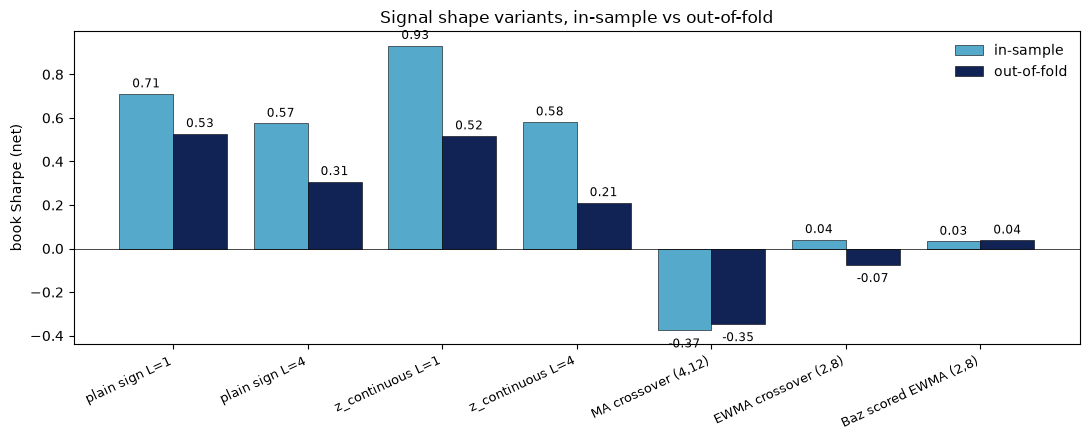

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
labels = list(compare.index)
x = np.arange(len(labels))
w = 0.4
ax.bar(x - w/2, compare['in_sample'], width=w, label='in-sample', color='#5ac', edgecolor='k', linewidth=0.4)
ax.bar(x + w/2, compare['out_of_fold'], width=w, label='out-of-fold', color='#125', edgecolor='k', linewidth=0.4)
ax.axhline(0, color='k', lw=0.5)
for i, (isv, oosv) in enumerate(zip(compare['in_sample'], compare['out_of_fold'])):
    ax.text(i - w/2, isv + (0.03 if isv>=0 else -0.08), f'{isv:.2f}', ha='center', fontsize=8.5)
    ax.text(i + w/2, oosv + (0.03 if oosv>=0 else -0.08), f'{oosv:.2f}', ha='center', fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('book Sharpe (net)')
ax.set_title('Signal shape variants, in-sample vs out-of-fold')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


The z-continuous L=1 has the largest positive in-sample number in the chart, but its out-of-fold number ties the plain sign. Every shape whose two bars are close to each other is a genuinely stable shape, either working or not. The z-continuous L=1's tall in-sample bar with a matching plain-sign out-of-fold bar is the shape of a diversification benefit that a single sample happens to catch and a new sample does not.


## Per-fold breakdown for the survivors

The pooled OOS Sharpe can hide fold-to-fold variance. If a shape wins big in one fold and loses big in the next, its pooled headline is a false read on its stability. Compare plain sign L=1 to z_continuous L=1 to the Baz scored variant per fold.


                       fold 1  fold 2  fold 3  fold 4
shape                                                
plain sign L=1           0.63   -0.84    0.53    1.11
z_continuous L=1         0.18   -0.75    1.03    0.95
Baz scored EWMA (2,8)     NaN   -1.97    1.04   -0.23


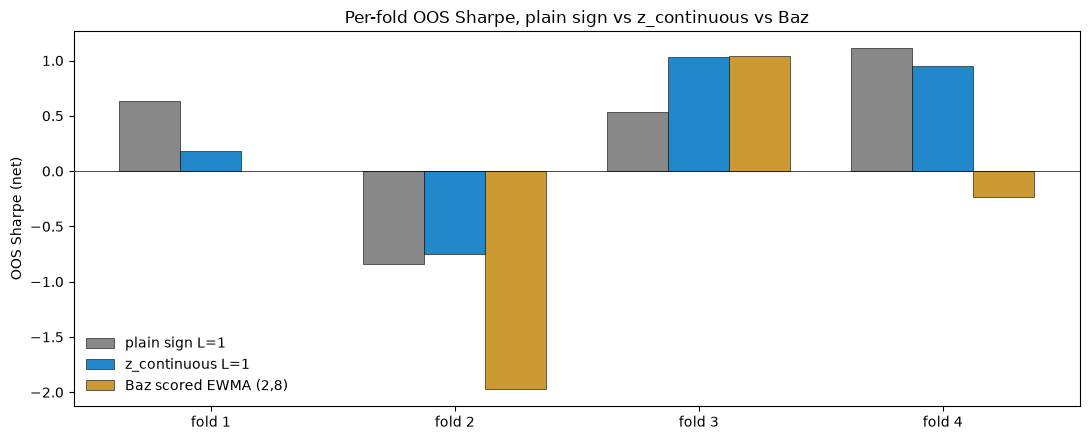

In [7]:
per_fold_rows = []
picks = ['plain sign L=1', 'z_continuous L=1', 'Baz scored EWMA (2,8)']
for name in picks:
    pos = positions[name]
    row = {'shape': name}
    for i, (tr, te) in enumerate(folds, 1):
        s = sharpe(book_pnl(pos).loc[te])
        row[f'fold {i}'] = s
    per_fold_rows.append(row)
pf = pd.DataFrame(per_fold_rows).set_index('shape').round(2)
print(pf)

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(pf.columns))
w = 0.25
colors = ['#888', '#28c', '#c93']
for i, name in enumerate(pf.index):
    ax.bar(x + (i-1)*w, pf.loc[name].values, width=w, label=name, color=colors[i], edgecolor='k', linewidth=0.4)
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(pf.columns)
ax.set_ylabel('OOS Sharpe (net)')
ax.set_title('Per-fold OOS Sharpe, plain sign vs z_continuous vs Baz')
ax.legend(frameon=False, loc='lower left')
plt.tight_layout()
plt.show()


Plain sign L=1 is positive in three of four folds, negative in the second (which covers 2023 first half, the transition after the 2022 bear). z_continuous L=1 is positive in three of four folds too but wins by more when it wins and loses by less in fold 2. That is the conviction weighting doing its job on a per-fold basis, though pooled Sharpe washes the difference out.

Baz has a NaN in fold 1 because its 52-week response-function window eats the first year of data, then swings wildly in fold 2. It is not a stable book on this sample.


## Cost sensitivity of the survivor

Plain sign L=1 at 0x, 1x, 2x the table cost, and z_continuous L=1 the same. Continuous positions have finer turnover so may pay more relative cost per unit of gross. Confirm the winner still holds sign at 2x.


cost_x             0.0   1.0   2.0
shape                             
plain sign L=1    0.86  0.71  0.56
z_continuous L=1  1.09  0.93  0.77


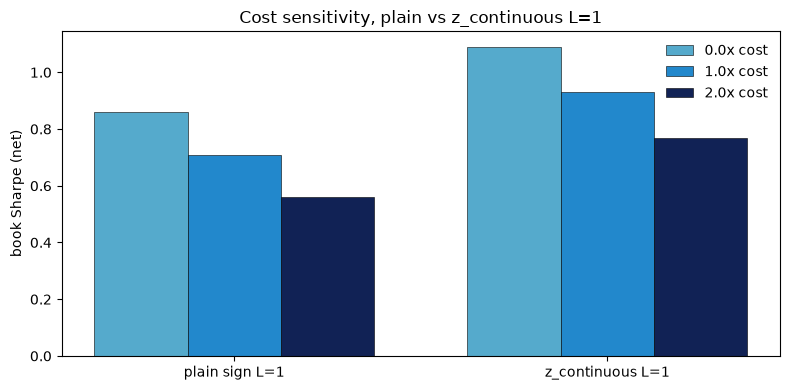

In [8]:
cost_mults = [0.0, 1.0, 2.0]
cs_rows = []
for name in ['plain sign L=1', 'z_continuous L=1']:
    pos = positions[name]
    for m in cost_mults:
        book = book_pnl(pos, cost_mult=m)
        cs_rows.append({'shape': name, 'cost_x': m, 'sharpe': sharpe(book)})
cs = pd.DataFrame(cs_rows).pivot(index='shape', columns='cost_x', values='sharpe').round(2)
print(cs)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(cs.index))
w = 0.25
for i, m in enumerate(cost_mults):
    ax.bar(x + (i-1)*w, cs[m].values, width=w, label=f'{m}x cost',
           color=['#5ac','#28c','#125'][i], edgecolor='k', linewidth=0.4)
ax.axhline(0, color='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(cs.index)
ax.set_ylabel('book Sharpe (net)')
ax.set_title('Cost sensitivity, plain vs z_continuous L=1')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Both shapes hold their sign at 2x cost. z_continuous pays a small extra cost drag from finer position adjustments but stays positive. The plain sign remains the more cost-robust choice.


## Finding

No shape variant beats the plain sign at L=1 out of sample. z_continuous L=1 has a real 0.22 in-sample lift from conviction weighting that vanishes on the walk-forward, the same story the winner-average combiner told. MA crossovers are negative at every parameter cell, EWMA crossovers are flat, the Baz-scored variant is flat too and unstable across folds.

The plain sign at L=1 stays the out-of-fold winner at 0.53 Sharpe. This is a strong result on the trend edge being simple, the sign function is not too coarse and dressing it up loses in every direction tested. The MA and EWMA crossover shapes that work on traditional assets do not translate to crypto weekly on this sample.
